In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_ROOT = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset")
IQ_DIR = DATASET_ROOT / "IQ"

first_iq = sorted(IQ_DIR.iterdir())[0]

print("IQ directory:", IQ_DIR)
print("First IQ file:", first_iq.name)

IQ directory: C:\Users\asus\Desktop\MATLAB_Dataset\IQ
First IQ file: Combined_LTE_DSSS_frame_1


In [3]:
with open(first_iq, "rb") as file:
    file.seek(8)
    raw_data = np.fromfile(file, dtype=np.float32)

I = raw_data[0::2]
Q = raw_data[1::2]

iq = I + 1j * Q

print("IQ samples:", len(iq))
print("I samples:", len(I))
print("Q samples:", len(Q))

IQ samples: 614400
I samples: 614400
Q samples: 614400


In [4]:
metadata_dir = DATASET_ROOT / "Metadata"
metadata_file = metadata_dir / f"{first_iq.name}.csv"

df = pd.read_csv(metadata_file)

sample_rate = float(df["LTE_SR"].iloc[0])

print("Sample rate:", sample_rate, "Hz")
print("Sample rate:", sample_rate / 1e6, "MHz")

Sample rate: 7680000.0 Hz
Sample rate: 7.68 MHz


In [5]:
N_PERSEG = 1024
N_OVERLAP = 512

print("Window: Hann")
print("Segment size:", N_PERSEG)
print("Overlap:", N_OVERLAP)
print("Frequency resolution:", sample_rate / N_PERSEG, "Hz")

Window: Hann
Segment size: 1024
Overlap: 512
Frequency resolution: 7500.0 Hz


In [6]:
from scipy.signal import stft

frequencies, times, Zxx = stft(
    iq,
    fs=sample_rate,
    window="hann",
    nperseg=N_PERSEG,
    noverlap=N_OVERLAP,
    return_onesided=False
)

print("STFT shape:", Zxx.shape)
print("Frequency bins:", len(frequencies))
print("Time bins:", len(times))

STFT shape: (1024, 1201)
Frequency bins: 1024
Time bins: 1201


In [7]:
stft_magnitude = np.abs(Zxx)

stft_db = 20 * np.log10(stft_magnitude + 1e-12)

print("Magnitude shape:", stft_magnitude.shape)
print("dB min:", stft_db.min())
print("dB max:", stft_db.max())

Magnitude shape: (1024, 1201)
dB min: -95.327
dB max: -6.3817024


C:\Users\asus\AppData\Local\Temp\ipykernel_25816\1859048157.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(


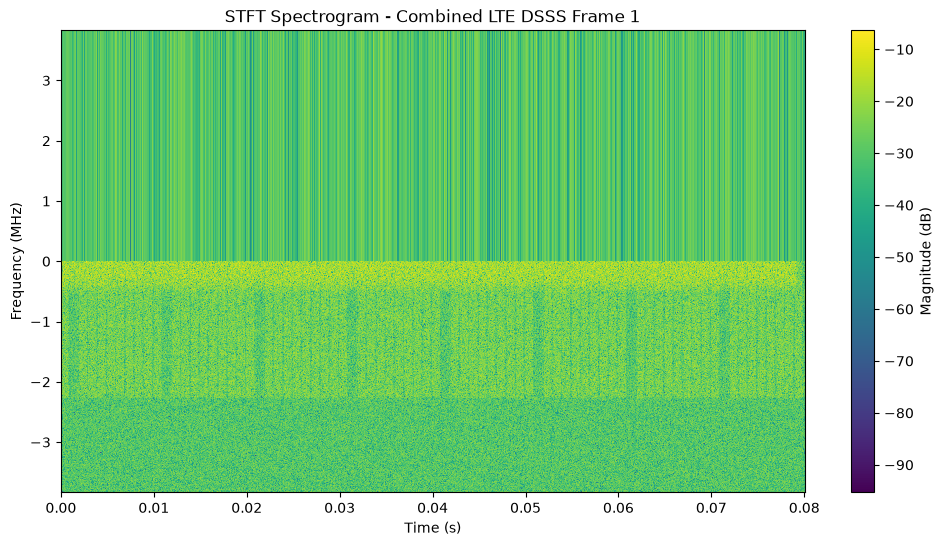

In [8]:
plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies / 1e6,
    stft_db,
    shading="auto"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("STFT Spectrogram - Combined LTE DSSS Frame 1")

plt.colorbar(label="Magnitude (dB)")

plt.show()

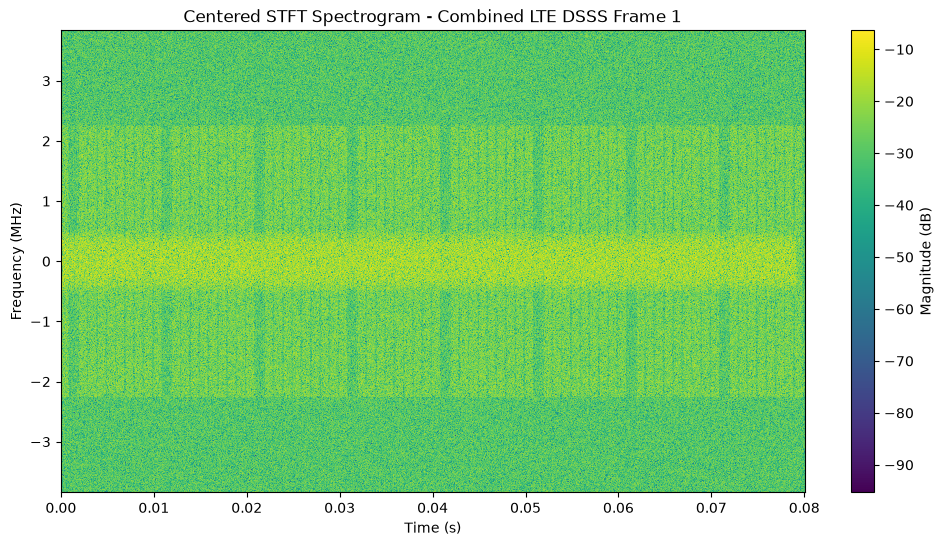

In [10]:
frequencies_shifted = np.fft.fftshift(frequencies)
stft_db_shifted = np.fft.fftshift(stft_db, axes=0)

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies_shifted / 1e6,
    stft_db_shifted,
    shading="auto"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Centered STFT Spectrogram - Combined LTE DSSS Frame 1")

plt.colorbar(label="Magnitude (dB)")

plt.show()

In [11]:
percentiles = np.percentile(
    stft_db_shifted,
    [1, 5, 10, 25, 50, 75, 90, 95, 99]
)

for p, value in zip(
    [1, 5, 10, 25, 50, 75, 90, 95, 99],
    percentiles
):
    print(f"{p}%: {value:.2f} dB")

1%: -46.26 dB
5%: -39.14 dB
10%: -35.95 dB
25%: -31.45 dB
50%: -27.21 dB
75%: -23.31 dB
90%: -19.86 dB
95%: -17.78 dB
99%: -13.96 dB


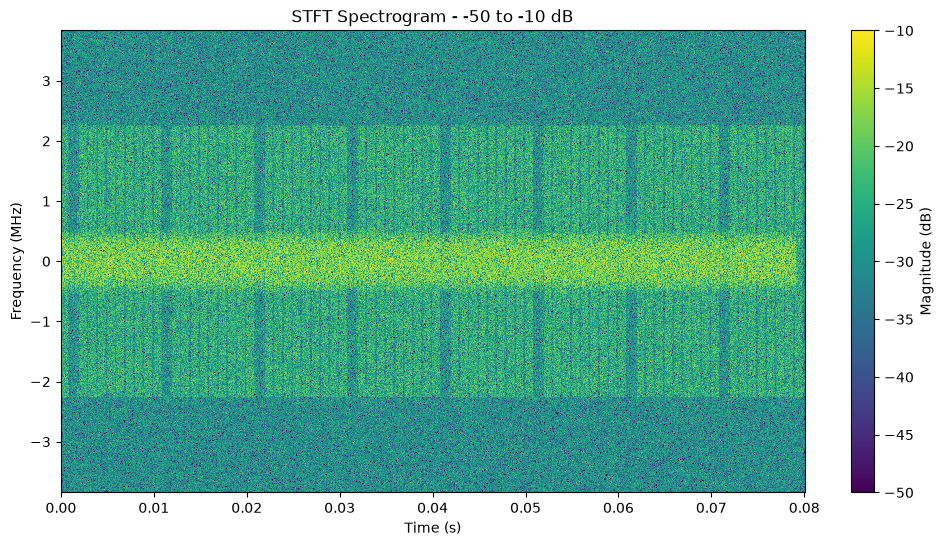

In [12]:
plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies_shifted / 1e6,
    stft_db_shifted,
    shading="auto",
    vmin=-50,
    vmax=-10
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("STFT Spectrogram - -50 to -10 dB")

plt.colorbar(label="Magnitude (dB)")

plt.show()

In [13]:
lte_files = sorted(
    [
        f for f in IQ_DIR.iterdir()
        if f.name.startswith("LTE_frame")
    ]
)

print("LTE files found:", len(lte_files))

if lte_files:
    print("Example:", lte_files[0].name)

LTE files found: 0


In [14]:
for file in sorted(IQ_DIR.iterdir())[:20]:
    print(file.name)

Combined_LTE_DSSS_frame_1
Combined_LTE_DSSS_frame_10
Combined_LTE_DSSS_frame_100
Combined_LTE_DSSS_frame_101
Combined_LTE_DSSS_frame_102
Combined_LTE_DSSS_frame_103
Combined_LTE_DSSS_frame_104
Combined_LTE_DSSS_frame_105
Combined_LTE_DSSS_frame_106
Combined_LTE_DSSS_frame_107
Combined_LTE_DSSS_frame_108
Combined_LTE_DSSS_frame_109
Combined_LTE_DSSS_frame_11
Combined_LTE_DSSS_frame_110
Combined_LTE_DSSS_frame_111
Combined_LTE_DSSS_frame_112
Combined_LTE_DSSS_frame_113
Combined_LTE_DSSS_frame_114
Combined_LTE_DSSS_frame_115
Combined_LTE_DSSS_frame_116


In [15]:
metadata_files = sorted((DATASET_ROOT / "Metadata").iterdir())

lte_file = None
dsss_file = None

for file in metadata_files:
    df_temp = pd.read_csv(file)

    signal_type = df_temp["Signal_Type"].iloc[0]

    if signal_type == "LTE" and lte_file is None:
        lte_file = file

    if signal_type == "LTE_DSSS" and dsss_file is None:
        dsss_file = file

print("LTE:", lte_file.name)
print("LTE+DSSS:", dsss_file.name)

LTE: OnlyLTE_frame_1.csv
LTE+DSSS: Combined_LTE_DSSS_frame_1.csv


In [16]:
def load_iq(file_name):
    iq_file = IQ_DIR / file_name

    with open(iq_file, "rb") as file:
        file.seek(8)
        raw = np.fromfile(file, dtype=np.float32)

    I = raw[0::2]
    Q = raw[1::2]

    return I + 1j * Q


lte_iq = load_iq("OnlyLTE_frame_1")
lte_dsss_iq = load_iq("Combined_LTE_DSSS_frame_1")

print("LTE samples:", len(lte_iq))
print("LTE+DSSS samples:", len(lte_dsss_iq))

LTE samples: 614400
LTE+DSSS samples: 614400


In [17]:
f_lte, t_lte, Z_lte = stft(
    lte_iq,
    fs=sample_rate,
    window="hann",
    nperseg=N_PERSEG,
    noverlap=N_OVERLAP,
    return_onesided=False
)

f_dsss, t_dsss, Z_dsss = stft(
    lte_dsss_iq,
    fs=sample_rate,
    window="hann",
    nperseg=N_PERSEG,
    noverlap=N_OVERLAP,
    return_onesided=False
)

lte_db = 20 * np.log10(np.abs(Z_lte) + 1e-12)
dsss_db = 20 * np.log10(np.abs(Z_dsss) + 1e-12)

f_lte = np.fft.fftshift(f_lte)
lte_db = np.fft.fftshift(lte_db, axes=0)

f_dsss = np.fft.fftshift(f_dsss)
dsss_db = np.fft.fftshift(dsss_db, axes=0)

print("LTE spectrogram shape:", lte_db.shape)
print("LTE+DSSS spectrogram shape:", dsss_db.shape)

LTE spectrogram shape: (1024, 1201)
LTE+DSSS spectrogram shape: (1024, 1201)


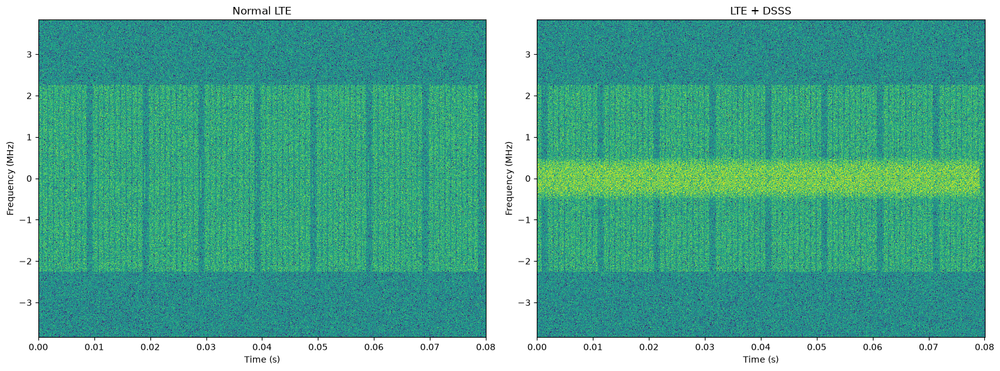

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vmin = -50
vmax = -10

axes[0].pcolormesh(
    t_lte,
    f_lte / 1e6,
    lte_db,
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title("Normal LTE")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (MHz)")

axes[1].pcolormesh(
    t_dsss,
    f_dsss / 1e6,
    dsss_db,
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("LTE + DSSS")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (MHz)")

plt.tight_layout()
plt.show()

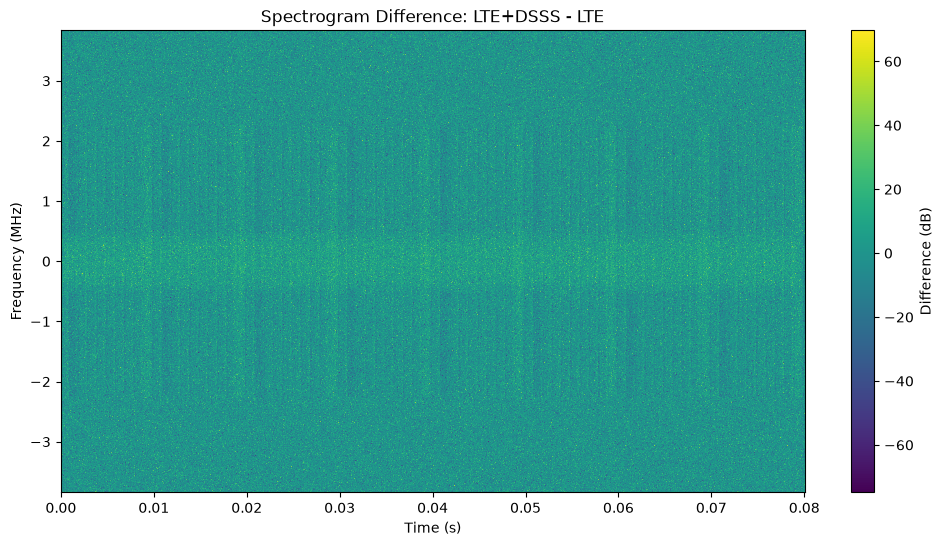

In [19]:
spectrogram_difference = dsss_db - lte_db

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    t_dsss,
    f_dsss / 1e6,
    spectrogram_difference,
    shading="auto"
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Spectrogram Difference: LTE+DSSS - LTE")
plt.colorbar(label="Difference (dB)")

plt.show()

In [20]:
mean_difference = np.mean(spectrogram_difference, axis=1)

peak_index = np.argmax(mean_difference)
peak_frequency = f_dsss[peak_index]

print("En yüksek ortalama fark:", mean_difference[peak_index], "dB")
print("Bu frekanstaki fark:", peak_frequency / 1e6, "MHz")

En yüksek ortalama fark: 8.1936035 dB
Bu frekanstaki fark: -0.0225 MHz


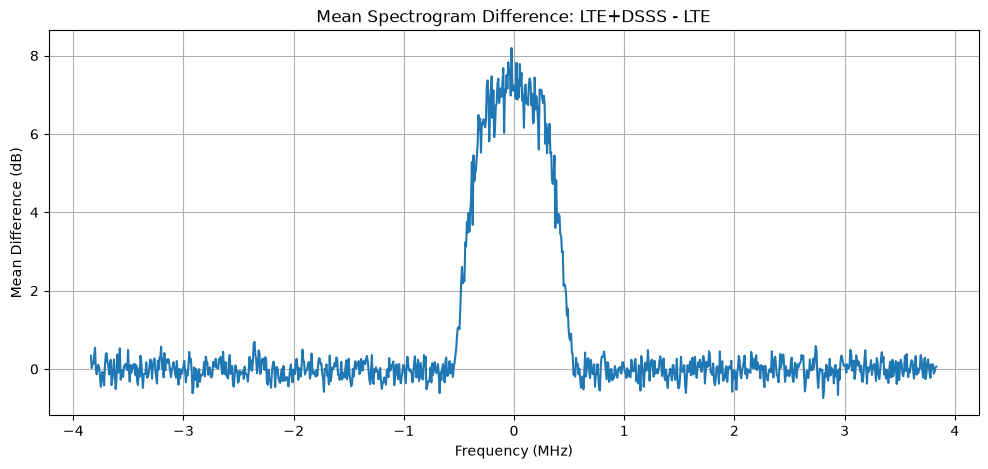

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    f_dsss / 1e6,
    mean_difference
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Mean Difference (dB)")
plt.title("Mean Spectrogram Difference: LTE+DSSS - LTE")
plt.grid()

plt.show()

In [22]:
N_PERSEG_256 = 256
N_OVERLAP_256 = 0

f_lte_256, t_lte_256, Z_lte_256 = stft(
    lte_iq,
    fs=sample_rate,
    window="hann",
    nperseg=N_PERSEG_256,
    noverlap=N_OVERLAP_256,
    return_onesided=False
)

f_dsss_256, t_dsss_256, Z_dsss_256 = stft(
    lte_dsss_iq,
    fs=sample_rate,
    window="hann",
    nperseg=N_PERSEG_256,
    noverlap=N_OVERLAP_256,
    return_onesided=False
)

lte_db_256 = 20 * np.log10(np.abs(Z_lte_256) + 1e-12)
dsss_db_256 = 20 * np.log10(np.abs(Z_dsss_256) + 1e-12)

f_lte_256 = np.fft.fftshift(f_lte_256)
lte_db_256 = np.fft.fftshift(lte_db_256, axes=0)

f_dsss_256 = np.fft.fftshift(f_dsss_256)
dsss_db_256 = np.fft.fftshift(dsss_db_256, axes=0)

print("LTE shape:", lte_db_256.shape)
print("LTE+DSSS shape:", dsss_db_256.shape)
print("Frequency resolution:", sample_rate / N_PERSEG_256, "Hz")

LTE shape: (256, 2401)
LTE+DSSS shape: (256, 2401)
Frequency resolution: 30000.0 Hz


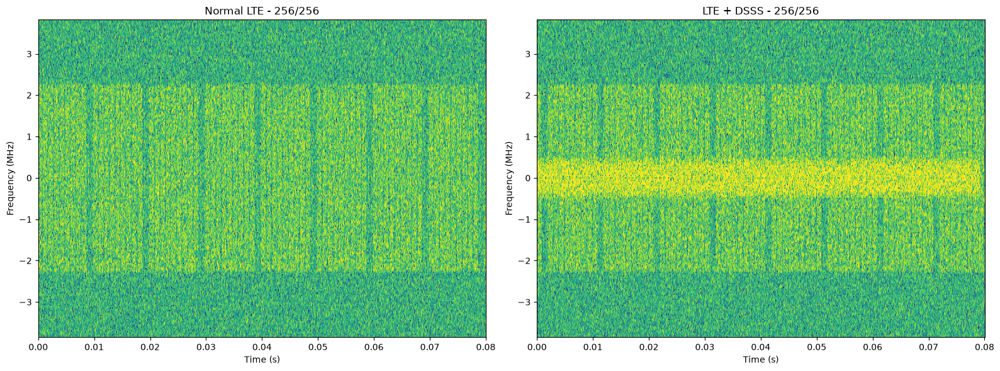

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vmin = -50
vmax = -10

axes[0].pcolormesh(
    t_lte_256,
    f_lte_256 / 1e6,
    lte_db_256,
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

axes[0].set_title("Normal LTE - 256/256")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Frequency (MHz)")

axes[1].pcolormesh(
    t_dsss_256,
    f_dsss_256 / 1e6,
    dsss_db_256,
    shading="auto",
    vmin=vmin,
    vmax=vmax
)

axes[1].set_title("LTE + DSSS - 256/256")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (MHz)")

plt.tight_layout()
plt.show()

In [24]:
difference_256 = dsss_db_256 - lte_db_256

mean_difference_256 = np.mean(difference_256, axis=1)

peak_index_256 = np.argmax(mean_difference_256)
peak_frequency_256 = f_dsss_256[peak_index_256]

print("256/256 en yüksek ortalama fark:",
      mean_difference_256[peak_index_256], "dB")

print("Frekans:",
      peak_frequency_256 / 1e6, "MHz")

256/256 en yüksek ortalama fark: 7.5015073 dB
Frekans: -0.03 MHz


In [25]:
stft_min = stft_db_shifted.min()
stft_max = stft_db_shifted.max()

stft_normalized = (
    stft_db_shifted - stft_min
) / (stft_max - stft_min)

print("Original min:", stft_min)
print("Original max:", stft_max)
print("Normalized min:", stft_normalized.min())
print("Normalized max:", stft_normalized.max())

Original min: -95.327
Original max: -6.3817024
Normalized min: 0.0
Normalized max: 1.0


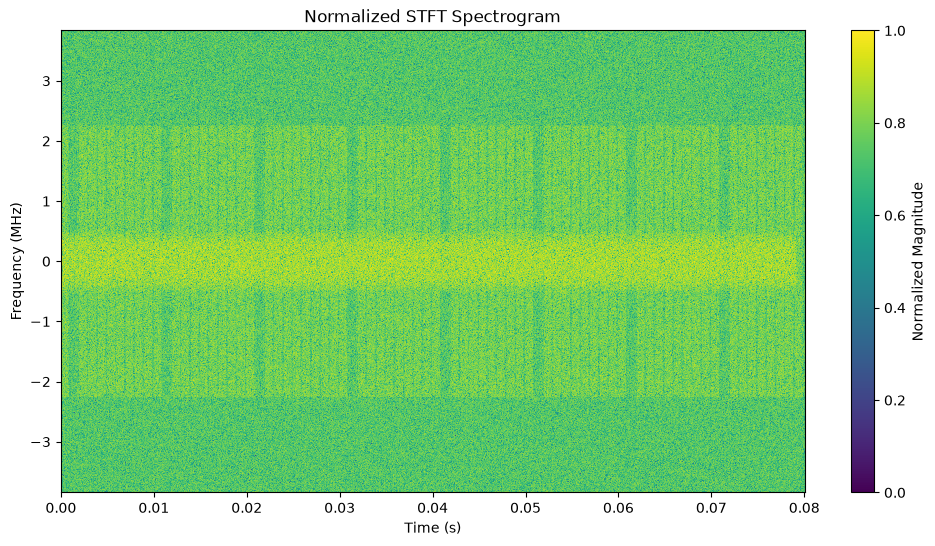

In [26]:
plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies_shifted / 1e6,
    stft_normalized,
    shading="auto",
    vmin=0,
    vmax=1
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Normalized STFT Spectrogram")
plt.colorbar(label="Normalized Magnitude")

plt.show()

In [27]:
stft_fixed_range = np.clip(
    (stft_db_shifted + 50) / 50,
    0,
    1
)

print("Fixed-range min:", stft_fixed_range.min())
print("Fixed-range max:", stft_fixed_range.max())

Fixed-range min: 0.0
Fixed-range max: 0.87236595


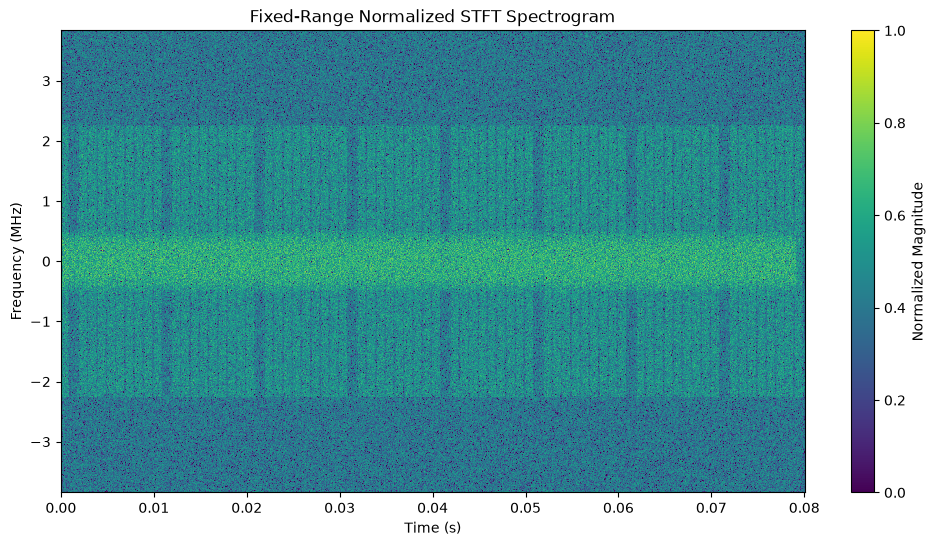

In [28]:
plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies_shifted / 1e6,
    stft_fixed_range,
    shading="auto",
    vmin=0,
    vmax=1
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Fixed-Range Normalized STFT Spectrogram")
plt.colorbar(label="Normalized Magnitude")

plt.show()

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.dsp.io import load_iq
from src.dsp.fft import compute_fft
from src.dsp.stft import compute_stft
from src.dsp.preprocessing import normalize_stft_db

print("DSP modules imported successfully.")

DSP modules imported successfully.


In [3]:
from pathlib import Path
import numpy as np

from src.dsp.io import load_iq

DATASET_ROOT = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset")
IQ_DIR = DATASET_ROOT / "IQ"

first_iq = sorted(IQ_DIR.iterdir())[0]

iq_test = load_iq(first_iq)

print("IQ file:", first_iq.name)
print("IQ samples:", len(iq_test))
print("First IQ sample:", iq_test[0])
print("RMS:", np.sqrt(np.mean(np.abs(iq_test) ** 2)))

IQ file: Combined_LTE_DSSS_frame_1
IQ samples: 614400
First IQ sample: (0.15985933-0.6266389j)
RMS: 1.7310002


In [4]:
from src.dsp.stft import compute_stft
from src.dsp.preprocessing import normalize_stft_db

sample_rate = 7_680_000

frequencies, times, magnitude, magnitude_db = compute_stft(
    iq_test,
    sample_rate
)

spectrogram = normalize_stft_db(magnitude_db)

print("STFT shape:", magnitude_db.shape)
print("Normalized shape:", spectrogram.shape)
print("Normalized min:", spectrogram.min())
print("Normalized max:", spectrogram.max())

STFT shape: (1024, 1201)
Normalized shape: (1024, 1201)
Normalized min: 0.0
Normalized max: 0.87236595


C:\Users\asus\AppData\Local\Temp\ipykernel_32424\3606556092.py:8: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(


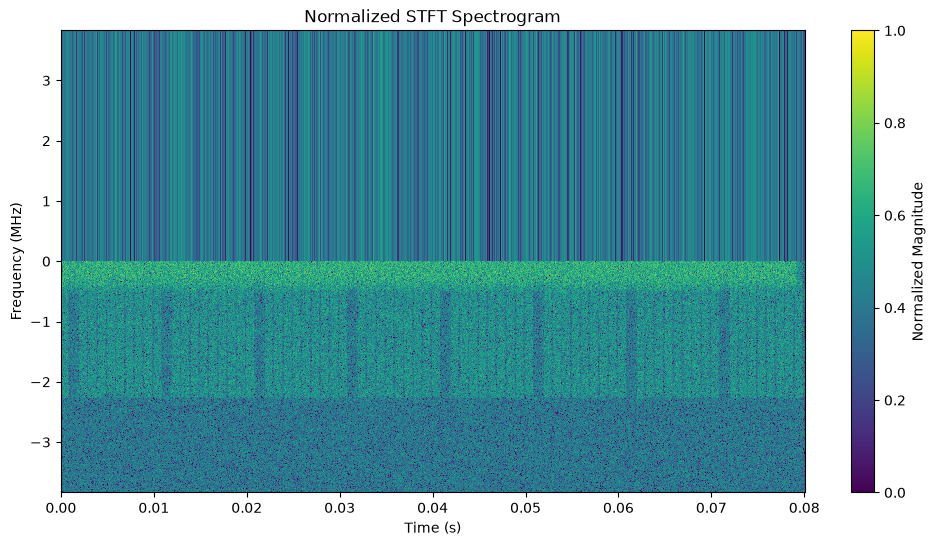

In [6]:
import matplotlib.pyplot as plt

frequencies_shifted = np.fft.fftshift(frequencies)
spectrogram_shifted = np.fft.fftshift(spectrogram, axes=0)

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies_shifted / 1e6,
    spectrogram_shifted,
    shading="auto",
    vmin=0,
    vmax=1
)

plt.xlabel("Time (s)")
plt.ylabel("Frequency (MHz)")
plt.title("Normalized STFT Spectrogram")
plt.colorbar(label="Normalized Magnitude")

plt.show()

In [7]:
spectrogram.shape

(1024, 1201)

In [8]:
X_test = spectrogram_shifted.astype(np.float32)

print("X_test shape:", X_test.shape)
print("X_test dtype:", X_test.dtype)
print("X_test min:", X_test.min())
print("X_test max:", X_test.max())

X_test shape: (1024, 1201)
X_test dtype: float32
X_test min: 0.0
X_test max: 0.87236595


In [9]:
from src.dsp.pipeline import process_iq_file

X_single = process_iq_file(
    first_iq,
    sample_rate
)

print("Shape:", X_single.shape)
print("Dtype:", X_single.dtype)
print("Min:", X_single.min())
print("Max:", X_single.max())

Shape: (1024, 1201)
Dtype: float32
Min: 0.0
Max: 0.87236595


In [10]:
from pathlib import Path
import pandas as pd

METADATA_DIR = DATASET_ROOT / "Metadata"

def get_label(iq_file_name):
    metadata_file = METADATA_DIR / f"{iq_file_name}.csv"
    metadata = pd.read_csv(metadata_file)

    signal_type = metadata["Signal_Type"].iloc[0]

    if signal_type == "LTE":
        return 0
    elif signal_type == "LTE_DSSS":
        return 1
    else:
        raise ValueError(f"Unknown Signal_Type: {signal_type}")

In [11]:
print("First file:", first_iq.name)
print("Label:", get_label(first_iq.name))

First file: Combined_LTE_DSSS_frame_1
Label: 1


In [12]:
iq_files = sorted(IQ_DIR.iterdir())

labels = [get_label(file.name) for file in iq_files]

print("Total IQ files:", len(iq_files))
print("Normal LTE:", labels.count(0))
print("LTE + DSSS:", labels.count(1))

Total IQ files: 408
Normal LTE: 120
LTE + DSSS: 288


In [13]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "datasets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: C:\Users\asus\Desktop\RF-Anomaly-Detection\outputs\datasets


In [14]:
X = []
y = []

for i, iq_file in enumerate(iq_files):
    print(f"Processing {i + 1}/{len(iq_files)}: {iq_file.name}")

    spectrogram = process_iq_file(
        iq_file,
        sample_rate
    )

    X.append(spectrogram)
    y.append(get_label(iq_file.name))

X = np.stack(X).astype(np.float32)
y = np.array(y, dtype=np.int64)

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)
print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

Processing 1/408: Combined_LTE_DSSS_frame_1
Processing 2/408: Combined_LTE_DSSS_frame_10
Processing 3/408: Combined_LTE_DSSS_frame_100
Processing 4/408: Combined_LTE_DSSS_frame_101
Processing 5/408: Combined_LTE_DSSS_frame_102
Processing 6/408: Combined_LTE_DSSS_frame_103
Processing 7/408: Combined_LTE_DSSS_frame_104
Processing 8/408: Combined_LTE_DSSS_frame_105
Processing 9/408: Combined_LTE_DSSS_frame_106
Processing 10/408: Combined_LTE_DSSS_frame_107
Processing 11/408: Combined_LTE_DSSS_frame_108
Processing 12/408: Combined_LTE_DSSS_frame_109
Processing 13/408: Combined_LTE_DSSS_frame_11
Processing 14/408: Combined_LTE_DSSS_frame_110
Processing 15/408: Combined_LTE_DSSS_frame_111
Processing 16/408: Combined_LTE_DSSS_frame_112
Processing 17/408: Combined_LTE_DSSS_frame_113
Processing 18/408: Combined_LTE_DSSS_frame_114
Processing 19/408: Combined_LTE_DSSS_frame_115
Processing 20/408: Combined_LTE_DSSS_frame_116
Processing 21/408: Combined_LTE_DSSS_frame_117
Processing 22/408: Combine

ValueError: all input arrays must have the same shape

In [15]:
from collections import Counter

shape_counts = Counter()

for iq_file in iq_files:
    spectrogram = process_iq_file(
        iq_file,
        sample_rate
    )
    shape_counts[spectrogram.shape] += 1

print("Spectrogram shapes:")
for shape, count in shape_counts.items():
    print(shape, "->", count, "files")

Spectrogram shapes:
(1024, 1201) -> 102 files
(1024, 2401) -> 102 files
(1024, 4801) -> 204 files


In [16]:
sample_counts = {}

for iq_file in iq_files:
    iq = load_iq(iq_file)
    sample_counts[iq_file.name] = len(iq)

from collections import Counter

count_distribution = Counter(sample_counts.values())

print("IQ sample count distribution:")

for sample_count, file_count in sorted(count_distribution.items()):
    print(sample_count, "samples ->", file_count, "files")

IQ sample count distribution:
614400 samples -> 102 files
1228800 samples -> 102 files
2457600 samples -> 204 files


In [17]:
duration_info = []

for iq_file in iq_files:
    metadata_file = METADATA_DIR / f"{iq_file.name}.csv"
    metadata = pd.read_csv(metadata_file)

    duration_info.append({
        "file": iq_file.name,
        "samples": len(load_iq(iq_file)),
        "signal_type": metadata["Signal_Type"].iloc[0],
        "sample_rate": metadata["LTE_SR"].iloc[0],
    })

duration_df = pd.DataFrame(duration_info)

print(duration_df.groupby(["samples", "signal_type"]).size())

samples  signal_type
614400   LTE             30
         LTE_DSSS        72
1228800  LTE             30
         LTE_DSSS        72
2457600  LTE             60
         LTE_DSSS       144
dtype: int64


In [18]:
WINDOW_SIZE = 131072

def get_window_starts(signal_length, window_size=WINDOW_SIZE, num_windows=4):
    if signal_length < window_size:
        raise ValueError("Signal is shorter than window size.")

    max_start = signal_length - window_size

    return np.linspace(
        0,
        max_start,
        num_windows,
        dtype=int
    )


# Kısa, orta ve uzun kayıttan birer örnek seç
example_files = [
    next(f for f in iq_files if len(load_iq(f)) == 614400),
    next(f for f in iq_files if len(load_iq(f)) == 1228800),
    next(f for f in iq_files if len(load_iq(f)) == 2457600),
]

for iq_file in example_files:
    iq = load_iq(iq_file)
    starts = get_window_starts(len(iq))

    print(f"\n{iq_file.name}")
    print(f"Total samples: {len(iq)}")
    print("Window starts:", starts)
    print("Window ends:", starts + WINDOW_SIZE)


Combined_LTE_DSSS_frame_1
Total samples: 614400
Window starts: [     0 161109 322218 483328]
Window ends: [131072 292181 453290 614400]

Combined_LTE_DSSS_frame_100
Total samples: 1228800
Window starts: [      0  365909  731818 1097728]
Window ends: [ 131072  496981  862890 1228800]

Combined_LTE_DSSS_frame_145
Total samples: 2457600
Window starts: [      0  775509 1551018 2326528]
Window ends: [ 131072  906581 1682090 2457600]


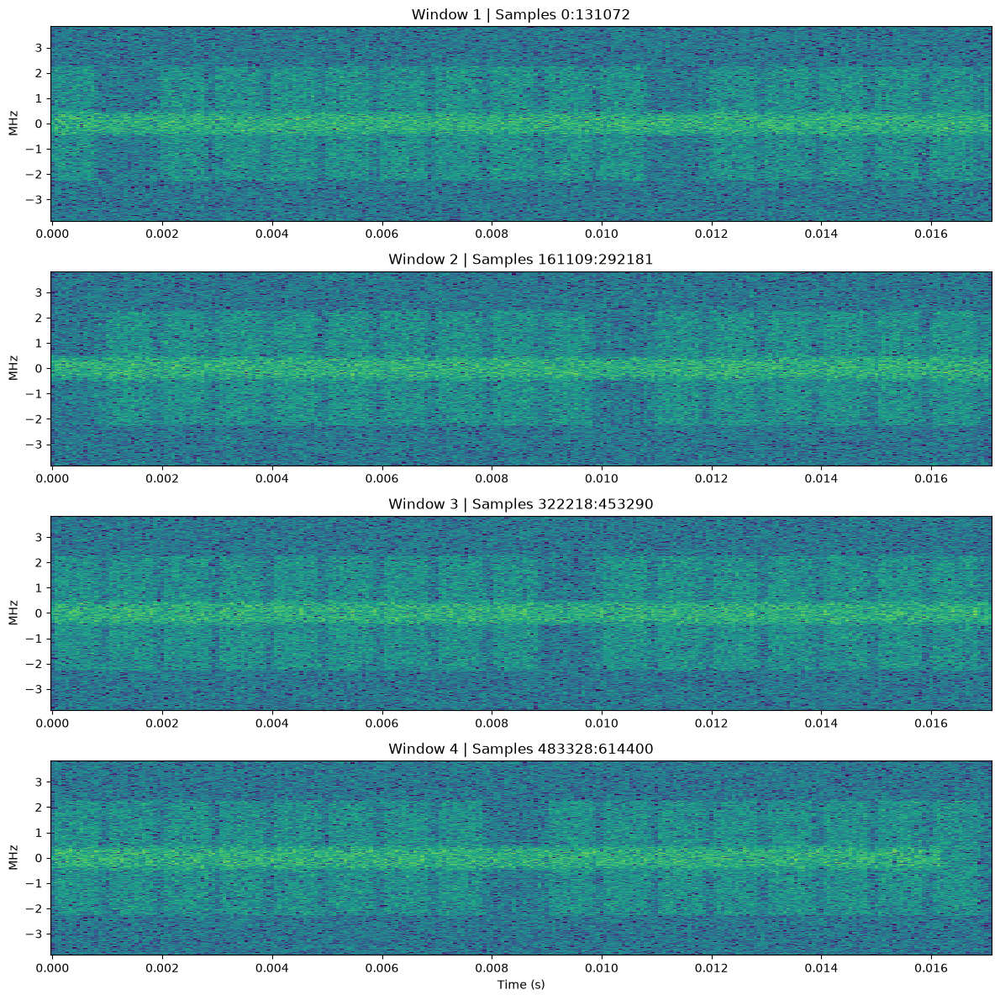

In [19]:
from scipy.signal import stft

test_file = next(
    f for f in iq_files
    if f.name == "Combined_LTE_DSSS_frame_1"
)

iq = load_iq(test_file)

starts = get_window_starts(len(iq))

fig, axes = plt.subplots(4, 1, figsize=(12, 12))

for i, start in enumerate(starts):
    iq_window = iq[start:start + WINDOW_SIZE]

    frequencies, times, Zxx = stft(
        iq_window,
        fs=sample_rate,
        window="hann",
        nperseg=1024,
        noverlap=512,
        return_onesided=False,
    )

    Zxx = np.fft.fftshift(Zxx, axes=0)
    frequencies = np.fft.fftshift(frequencies)

    magnitude_db = 20 * np.log10(np.abs(Zxx) + 1e-12)

    axes[i].pcolormesh(
        times,
        frequencies / 1e6,
        magnitude_db,
        shading="auto",
        vmin=-50,
        vmax=0,
    )

    axes[i].set_ylabel("MHz")
    axes[i].set_title(f"Window {i + 1} | Samples {start}:{start + WINDOW_SIZE}")

axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.dsp.io import load_iq
from src.dsp.stft import compute_stft

In [21]:
IQ_DIR = Path(r"C:\Users\asus\Desktop\MATLAB_Dataset\IQ")

iq_files = list(IQ_DIR.glob("*"))

print("Dosya sayısı:", len(iq_files))
print("İlk dosya:", iq_files[0].name)

Dosya sayısı: 408
İlk dosya: Combined_LTE_DSSS_frame_1


In [22]:
iq_path = iq_files[0]

iq = load_iq(iq_path)

print("Dosya:", iq_path.name)
print("IQ sample sayısı:", len(iq))
print("İlk 5 IQ örneği:")
print(iq[:5])

Dosya: Combined_LTE_DSSS_frame_1
IQ sample sayısı: 614400
İlk 5 IQ örneği:
[0.15985933-0.6266389j  0.40331617-0.08912716j 0.9642415 +0.22925314j
 0.6673288 -0.6440841j  1.3007387 -0.10430895j]


In [23]:
FS = 7.68e6

frequencies, times, magnitude, magnitude_db = compute_stft(
    iq,
    sample_rate=FS,
    nperseg=1024,
    noverlap=512
)

print("STFT shape:", magnitude.shape)
print("Frequency bins:", len(frequencies))
print("Time bins:", len(times))
print("Frequency resolution:", FS / 1024, "Hz")

STFT shape: (1024, 1201)
Frequency bins: 1024
Time bins: 1201
Frequency resolution: 7500.0 Hz


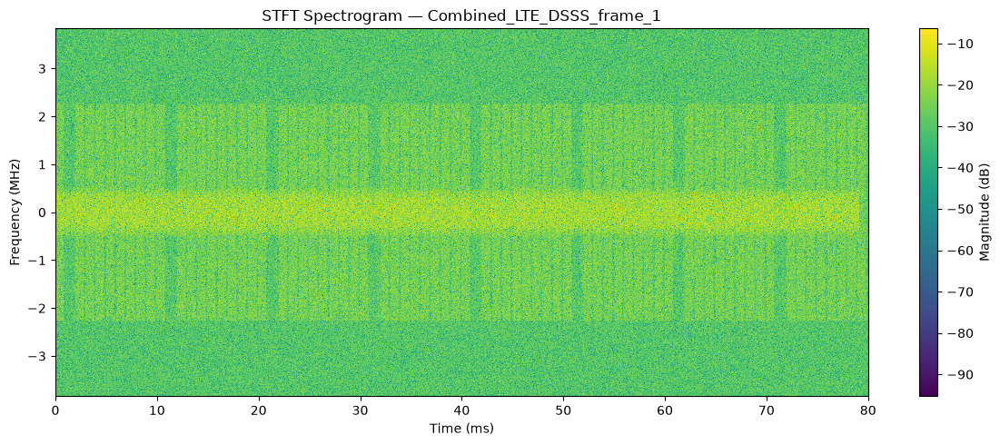

In [24]:
plt.figure(figsize=(12, 5))

plt.pcolormesh(
    times * 1e3,
    frequencies / 1e6,
    magnitude_db,
    shading="auto"
)

plt.xlabel("Time (ms)")
plt.ylabel("Frequency (MHz)")
plt.title(f"STFT Spectrogram — {iq_path.name}")
plt.colorbar(label="Magnitude (dB)")

plt.tight_layout()
plt.show()

In [25]:
lte_files = [
    f for f in iq_files
    if "OnlyLTE" in f.name
]

print("Normal LTE dosya sayısı:", len(lte_files))
print("İlk LTE dosyası:", lte_files[0].name)

Normal LTE dosya sayısı: 120
İlk LTE dosyası: OnlyLTE_frame_1


In [26]:
lte_path = lte_files[0]
lte_iq = load_iq(lte_path)

lte_f, lte_t, lte_mag, lte_db = compute_stft(
    lte_iq,
    sample_rate=FS,
    nperseg=1024,
    noverlap=512
)

print("Dosya:", lte_path.name)
print("IQ sample sayısı:", len(lte_iq))
print("STFT shape:", lte_db.shape)

Dosya: OnlyLTE_frame_1
IQ sample sayısı: 614400
STFT shape: (1024, 1201)


In [27]:
WINDOW_SIZE = 131072

max_start = len(iq) - WINDOW_SIZE
starts = np.linspace(0, max_start, 4, dtype=int)

print("Window starts:", starts)
print("Window size:", WINDOW_SIZE)

windows = [
    iq[start:start + WINDOW_SIZE]
    for start in starts
]

print("Number of windows:", len(windows))
print("Each window:", [len(w) for w in windows])

Window starts: [     0 161109 322218 483328]
Window size: 131072
Number of windows: 4
Each window: [131072, 131072, 131072, 131072]
